# DCE Distribution Diagnostics

This notebook prepares three diagnostics requested for the DCE functional-form:

1. A descriptive statistics table for the four baseline 25 km DCE variables.
2. Raw-scale density plots of non-zero `DCE2020-2024` values by calendar year (2020-2024), with five buffer definitions (15/25/50/100/200 km) shown in each year panel.
3. A unique-coal-unit distribution of the distance to the nearest operating data center, where each coal unit appears once.

No log transformation is used in the figures.


In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

try:
    from scipy.stats import gaussian_kde
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

current = Path.cwd()
while current.name != 'Data_center_and_fossil_energy_Replication':
    if current.parent == current:
        raise RuntimeError('Could not find Data_center_and_fossil_energy_Replication root')
    current = current.parent

BASE_PATH = current
RAW = BASE_PATH / 'Data' / 'raw'
USE = BASE_PATH / 'Data' / 'use'
TEMP = BASE_PATH / 'Data' / 'temp'
FIGURES = BASE_PATH / 'Results' / 'Figures'
TABLES = BASE_PATH / 'Results' / 'Tables'

for path in [TEMP, FIGURES, TABLES]:
    path.mkdir(parents=True, exist_ok=True)

DATA_PATH = USE / 'gem_coal_plants_multi_record_sa_dce_robust_forR_clean.dta'
AI_PATH = RAW / 'SPGlobal_Export.xlsx'

print(f'BASE_PATH: {BASE_PATH}')
print(f'DCE panel data: {DATA_PATH}')
print(f'Data center data: {AI_PATH}')
print(f'Gaussian KDE available: {HAS_SCIPY}')


In [50]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.linewidth': 0.6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'axes.labelsize': 7,
    'legend.fontsize': 6,
    'figure.dpi': 300,
})

BUFFERS = [15, 25, 50, 100, 200]
PERIODS = ['before06', '06_15', '16_19', '20_24']
YEARS = [2020, 2021, 2022, 2023, 2024]

COLORS = {
    15: '#4C78A8',
    25: '#F58518',
    50: '#54A24B',
    100: '#B279A2',
    200: '#E45756',
}
COLOR_MAIN = '#3B6FB6'
COLOR_ACCENT = '#D95F02'


def savefig(fig, name):
    tif = FIGURES / f'{name}.tif'
    pdf = FIGURES / f'{name}.pdf'
    fig.savefig(tif, dpi=300, bbox_inches='tight', pil_kwargs={'compression': 'tiff_lzw'})
    fig.savefig(pdf, bbox_inches='tight')
    print(f'Saved: {tif}')
    print(f'Saved: {pdf}')


In [51]:
def haversine_km(lat1, lon1, lat2_array, lon2_array):
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2_array)
    lon2_rad = np.radians(lon2_array)
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c


def describe_dce(series, name):
    s = series.dropna()
    pos = s[s > 0]
    return {
        'variable': name,
        'n': len(s),
        'zero_n': int((s == 0).sum()),
        'zero_share': float((s == 0).mean()),
        'nonzero_n': int((s > 0).sum()),
        'nonzero_share': float((s > 0).mean()),
        'mean': s.mean(),
        'sd': s.std(),
        'min': s.min(),
        'p25': s.quantile(0.25),
        'median': s.median(),
        'p75': s.quantile(0.75),
        'p90': s.quantile(0.90),
        'p95': s.quantile(0.95),
        'p99': s.quantile(0.99),
        'max': s.max(),
        'positive_mean': pos.mean() if len(pos) else np.nan,
        'positive_median': pos.median() if len(pos) else np.nan,
        'positive_p90': pos.quantile(0.90) if len(pos) else np.nan,
        'positive_p95': pos.quantile(0.95) if len(pos) else np.nan,
        'positive_p99': pos.quantile(0.99) if len(pos) else np.nan,
        'positive_max': pos.max() if len(pos) else np.nan,
    }


def draw_density(ax, values, xmax, color, label):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    values = values[(values > 0) & (values <= xmax)]
    if len(values) < 3:
        return
    if HAS_SCIPY and np.unique(values).size >= 3:
        grid = np.linspace(0, xmax, 200)
        kde = gaussian_kde(values)
        ax.plot(grid, kde(grid), color=color, lw=1.0, label=label)
    else:
        bins = np.linspace(0, xmax, 45)
        ax.hist(values, bins=bins, histtype='step', density=True, color=color, lw=1.0, label=label)


In [52]:
df = pd.read_stata(DATA_PATH)
print(f'Loaded panel records: {len(df):,}')
print(f'Unique coal units: {df["GEM_unit_phase_ID"].nunique():,}')
print(f'Calendar year range: {df["year"].min():.0f}-{df["year"].max():.0f}')

required = [f'ai_proximity_{b}km_{p}' for b in BUFFERS for p in PERIODS]
missing = [v for v in required if v not in df.columns]
if missing:
    raise KeyError(f'Missing DCE variables. Run dce_calculate_robust.ipynb and prepared_dataset_robust.do first. Missing: {missing[:8]}')


Loaded panel records: 259,044
Unique coal units: 9,379
Calendar year range: 1927-2024


## 1. Baseline 25 km DCE Descriptive Statistics

In [53]:
dce25_vars = [f'ai_proximity_25km_{p}' for p in PERIODS]
summary_25km = pd.DataFrame([describe_dce(df[v], v) for v in dce25_vars])
summary_25km_path = TABLES / 'dce_25km_four_periods_full_sample_summary.csv'
summary_25km.to_csv(summary_25km_path, index=False)
summary_25km


,variable,n,zero_n,zero_share,nonzero_n,nonzero_share,mean,sd,min,p25,...,p90,p95,p99,max,positive_mean,positive_median,positive_p90,positive_p95,positive_p99,positive_max
0,ai_proximity_25km_before06,259044,243723,0.940856,15321,0.059144,0.192738,2.644935,0.0,0.0,...,0.0,0.508962,3.806193,210.134170,3.258772,1.239813,6.517093,9.378274,35.424663,210.134170
1,ai_proximity_25km_06_15,259044,243977,0.941836,15067,0.058164,0.306644,4.097575,0.0,0.0,...,0.0,0.535421,6.715052,396.988004,5.272070,1.776247,12.814061,21.233180,46.449199,396.988004
2,ai_proximity_25km_16_19,259044,252849,0.976085,6195,0.023915,0.097306,1.632075,0.0,0.0,...,0.0,0.000000,2.031616,231.800309,4.068852,1.519816,9.679199,14.642760,36.167595,231.800309
3,ai_proximity_25km_20_24,259044,255646,0.986883,3398,0.013117,0.060456,1.100182,0.0,0.0,...,0.0,0.000000,0.858001,150.090730,4.608843,1.766481,11.481217,17.539720,45.367469,150.090730


## 2. DCE2020-2024 Non-Zero Distributions by Calendar Year and Buffer

For each calendar year from 2020 to 2024, the plot shows the raw-scale density of non-zero `DCE2020-2024` values across five buffer definitions. Zeros are summarized in the accompanying table through the non-zero share, rather than being mixed into the density plot.

In [54]:
# Summary table for DCE2020-2024 by year and buffer, including zero/non-zero prevalence.
rows = []
for y in YEARS:
    data_y = df[df['year'] == y]
    for b in BUFFERS:
        v = f'ai_proximity_{b}km_20_24'
        row = describe_dce(data_y[v], v)
        row['year'] = y
        row['buffer_km'] = b
        rows.append(row)

post2020_year_buffer_summary = pd.DataFrame(rows)
post2020_year_buffer_summary_path = TABLES / 'dce_post2020_by_year_buffer_summary.csv'
post2020_year_buffer_summary.to_csv(post2020_year_buffer_summary_path, index=False)
post2020_year_buffer_summary.head(10)


,variable,n,zero_n,zero_share,nonzero_n,nonzero_share,mean,sd,min,p25,...,p99,max,positive_mean,positive_median,positive_p90,positive_p95,positive_p99,positive_max,year,buffer_km
0,ai_proximity_15km_20_24,6657,6465,0.971158,192,0.028842,0.103721,1.024186,0.0,0.0,...,2.412021,22.683735,3.596191,1.696370,9.876259,16.990941,22.683735,22.683735,2020,15
1,ai_proximity_25km_20_24,6657,6291,0.945020,366,0.054980,0.150960,1.145983,0.0,0.0,...,3.372445,22.683735,2.745738,1.270961,5.661023,10.851732,20.374120,22.683735,2020,25
2,ai_proximity_50km_20_24,6657,5996,0.900706,661,0.099294,0.213122,1.264493,0.0,0.0,...,5.054464,22.683735,2.146370,0.936924,5.054464,6.573995,20.173903,22.683735,2020,50
3,ai_proximity_100km_20_24,6657,5386,0.809073,1271,0.190927,0.297208,1.411868,0.0,0.0,...,5.841254,22.683735,1.556657,0.530732,3.875701,5.909300,18.617591,22.683735,2020,100
4,ai_proximity_200km_20_24,6657,4088,0.614090,2569,0.385910,0.421443,1.530382,0.0,0.0,...,6.887721,22.683735,1.092077,0.285199,2.827416,4.662162,10.804599,22.683735,2020,200
5,ai_proximity_15km_20_24,6555,6235,0.951182,320,0.048818,0.232032,1.844853,0.0,0.0,...,6.331558,51.009170,4.753035,2.153170,13.445574,22.923878,28.803986,51.009170,2021,15
6,ai_proximity_25km_20_24,6555,6009,0.916705,546,0.083295,0.321921,2.046962,0.0,0.0,...,7.727054,51.009170,3.864824,1.528110,9.460921,17.539720,28.196632,51.009170,2021,25
7,ai_proximity_50km_20_24,6555,5630,0.858886,925,0.141114,0.449481,2.304990,0.0,0.0,...,11.020779,51.009170,3.185241,1.121758,8.493831,12.533039,28.875685,51.009170,2021,50
8,ai_proximity_100km_20_24,6555,4802,0.732571,1753,0.267429,0.632436,2.624933,0.0,0.0,...,12.979881,51.009170,2.364870,0.620719,6.428379,11.657558,22.683735,51.009170,2021,100
9,ai_proximity_200km_20_24,6555,3148,0.480244,3407,0.519756,0.893612,2.874644,0.0,0.0,...,14.307164,51.009170,1.719292,0.383086,5.045914,8.727432,17.508661,51.009170,2021,200


In [ ]:
# Figure: five year panels, each with five buffer density curves.
# The x-axis is raw DCE and is truncated at the 99th percentile of all positive DCE2020-2024 values
# across the plotted year-buffer combinations to keep the bulk of the distribution visible.
all_positive = []
for y in YEARS:
    data_y = df[df['year'] == y]
    for b in BUFFERS:
        v = f'ai_proximity_{b}km_20_24'
        vals = data_y.loc[data_y[v] > 0, v].to_numpy()
        if len(vals):
            all_positive.append(vals)

all_positive = np.concatenate(all_positive) if all_positive else np.array([1.0])
xmax = np.quantile(all_positive, 0.99)

fig, axes = plt.subplots(1, 5, figsize=(9.2, 2.3), sharey=True)
for ax, y in zip(axes, YEARS):
    data_y = df[df['year'] == y]
    for b in BUFFERS:
        v = f'ai_proximity_{b}km_20_24'
        draw_density(ax, data_y[v].to_numpy(), xmax, COLORS[b], f'{b} km')
    ax.set_title(str(y), fontsize=7)
    ax.set_xlabel('DCE')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', ls='--', lw=0.3, alpha=0.25)

axes[0].set_ylabel('Density')
axes[-1].legend(frameon=False, loc='upper right')
fig.suptitle('Non-zero DCE2020-2024 distributions by year and buffer', fontsize=8, y=1.05)
fig.tight_layout()
savefig(fig, 'dce_post2020_nonzero_density_by_year_buffer')
plt.show()

print(f'X-axis truncated at pooled positive p99: {xmax:.4f}')


## 3. Unique Coal Unit to Nearest Operating Data Center Distance

Each coal unit appears once. For each unit, the nearest distance is calculated to data centers that had been built by the unit's last observed calendar year in the survival panel. Data centers are treated as operating after commissioning because retirement/closure years are not available in the S&P data.

In [ ]:
ai = pd.read_excel(AI_PATH, sheet_name='Sheet1')
ai['YR_BUILT'] = pd.to_numeric(ai['YR_BUILT'], errors='coerce')
ai = ai.dropna(subset=['LATITUDE', 'LONGITUDE', 'YR_BUILT']).copy()
ai = ai[ai['YR_BUILT'] != 2025].copy()
ai['YR_BUILT'] = ai['YR_BUILT'].astype(int)

ai_lat = ai['LATITUDE'].to_numpy(float)
ai_lon = ai['LONGITUDE'].to_numpy(float)
ai_year = ai['YR_BUILT'].to_numpy(int)

coal_units = (
    df[['GEM_unit_phase_ID', 'year', 'Latitude', 'Longitude']]
    .dropna(subset=['Latitude', 'Longitude', 'year'])
    .groupby('GEM_unit_phase_ID', as_index=False)
    .agg(last_observed_year=('year', 'max'), Latitude=('Latitude', 'first'), Longitude=('Longitude', 'first'))
)

nearest_rows = []
for _, row in coal_units.iterrows():
    valid_ai = ai_year <= int(row['last_observed_year'])
    if not valid_ai.any():
        nearest_d = np.nan
        n_operating = 0
    else:
        d = haversine_km(row['Latitude'], row['Longitude'], ai_lat[valid_ai], ai_lon[valid_ai])
        nearest_d = d.min()
        n_operating = int(valid_ai.sum())
    nearest_rows.append({
        'GEM_unit_phase_ID': row['GEM_unit_phase_ID'],
        'last_observed_year': int(row['last_observed_year']),
        'nearest_operating_dc_km': nearest_d,
        'operating_dc_available_n': n_operating,
    })

nearest_units = pd.DataFrame(nearest_rows)
nearest_units_path = TEMP / 'coal_unit_nearest_operating_dc_unique_units.csv'
nearest_units.to_csv(nearest_units_path, index=False)
print(f'Saved unique-unit nearest-distance data: {nearest_units_path}')
print(f'Coal units: {len(nearest_units):,}')
nearest_units.head()


In [57]:
def describe_distance(s, label):
    s = s.dropna()
    return {
        'sample': label,
        'n_units': len(s),
        'mean_km': s.mean(),
        'sd_km': s.std(),
        'min_km': s.min(),
        'p10_km': s.quantile(0.10),
        'p25_km': s.quantile(0.25),
        'median_km': s.median(),
        'p75_km': s.quantile(0.75),
        'p90_km': s.quantile(0.90),
        'p95_km': s.quantile(0.95),
        'p99_km': s.quantile(0.99),
        'max_km': s.max(),
        'n_within_15km': int((s <= 15).sum()),
        'n_within_25km': int((s <= 25).sum()),
        'n_within_50km': int((s <= 50).sum()),
        'n_within_100km': int((s <= 100).sum()),
        'n_within_200km': int((s <= 200).sum()),
        'share_within_25km': float((s <= 25).mean()),
    }

distance_summary = pd.DataFrame([
    describe_distance(nearest_units['nearest_operating_dc_km'], 'unique coal units')
])
distance_summary_path = TABLES / 'coal_unit_nearest_operating_dc_unique_units_summary.csv'
distance_summary.to_csv(distance_summary_path, index=False)
distance_summary


,sample,n_units,mean_km,sd_km,min_km,p10_km,p25_km,median_km,p75_km,p90_km,p95_km,p99_km,max_km,n_within_15km,n_within_25km,n_within_50km,n_within_100km,n_within_200km,share_within_25km
0,unique coal units,9379,147.747441,224.115332,0.060572,9.693691,27.280469,80.265103,168.518334,307.808118,493.454776,1084.73849,3070.318931,1426,2203,3436,5355,7475,0.234886


Saved threshold coverage table: /Users/lichenglin/Library/CloudStorage/OneDrive-HKUST(Guangzhou)/Data_center_and_fossil_energy_Replication/Results/Tables/coal_unit_nearest_operating_dc_distance_threshold_coverage.csv
Saved: /Users/lichenglin/Library/CloudStorage/OneDrive-HKUST(Guangzhou)/Data_center_and_fossil_energy_Replication/Results/Figures/coal_unit_nearest_operating_dc_distance_unique_units.tif
Saved: /Users/lichenglin/Library/CloudStorage/OneDrive-HKUST(Guangzhou)/Data_center_and_fossil_energy_Replication/Results/Figures/coal_unit_nearest_operating_dc_distance_unique_units.pdf


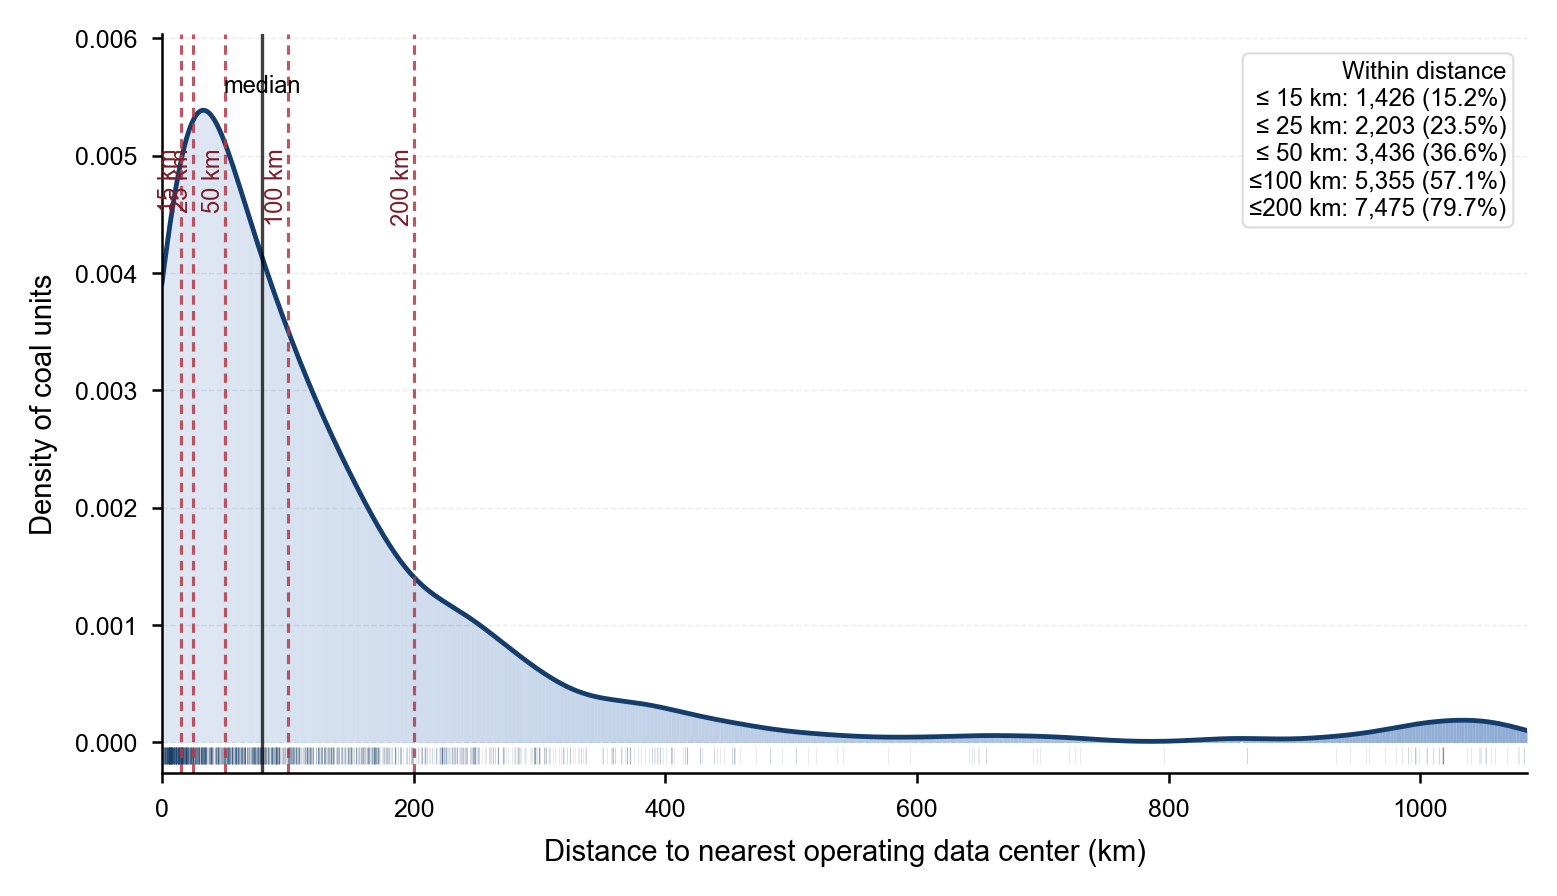

X-axis truncated at p99: 1084.74 km


,threshold_km,coal_units_within_threshold,share_of_coal_units
0,15,1426,0.152042
1,25,2203,0.234886
2,50,3436,0.366350
3,100,5355,0.570956
4,200,7475,0.796993


In [58]:
# Figure: unique coal unit distance to nearest operating data center.
# Smooth raw-scale density with a subtle gradient fill, p99-truncated for readability.
# The inset reports how many unique coal units are covered by each buffer threshold.
dist = nearest_units['nearest_operating_dc_km'].dropna().to_numpy()
xmax = np.quantile(dist, 0.99)
dist_plot = dist[dist <= xmax]

coverage_rows = []
for threshold in [15, 25, 50, 100, 200]:
    n_within = int((dist <= threshold).sum())
    coverage_rows.append({
        'threshold_km': threshold,
        'coal_units_within_threshold': n_within,
        'share_of_coal_units': n_within / len(dist),
    })
coverage_df = pd.DataFrame(coverage_rows)
coverage_path = TABLES / 'coal_unit_nearest_operating_dc_distance_threshold_coverage.csv'
coverage_df.to_csv(coverage_path, index=False)
print(f'Saved threshold coverage table: {coverage_path}')

fig, ax = plt.subplots(figsize=(5.2, 3.0))

if HAS_SCIPY and len(np.unique(dist_plot)) >= 3:
    grid = np.linspace(0, xmax, 500)
    kde = gaussian_kde(dist_plot)
    density = kde(grid)
else:
    density, edges = np.histogram(dist_plot, bins=80, range=(0, xmax), density=True)
    grid = (edges[:-1] + edges[1:]) / 2

base_color = np.array([59/255, 111/255, 182/255])
for i in range(len(grid) - 1):
    alpha = 0.16 + 0.42 * (i / max(len(grid) - 2, 1))
    ax.fill_between(grid[i:i+2], density[i:i+2], color=base_color, alpha=alpha, linewidth=0)

ax.plot(grid, density, color='#143D6B', lw=1.15)

rng = np.random.default_rng(42)
rug_sample = dist_plot if len(dist_plot) <= 1800 else rng.choice(dist_plot, 1800, replace=False)
rug_y0 = -density.max() * 0.035
rug_y1 = -density.max() * 0.008
ax.vlines(rug_sample, rug_y0, rug_y1, color='#143D6B', alpha=0.10, lw=0.25)

thresholds = [(15, '15'), (25, '25'), (50, '50'), (100, '100'), (200, '200')]
for x, lab in thresholds:
    if x <= xmax:
        ax.axvline(x, color='#B23A48', lw=0.75, ls=(0, (3, 2)), alpha=0.85)
        ax.text(x, density.max() * 0.94, f'{lab} km', rotation=90,
                va='top', ha='right', fontsize=5.7, color='#7A1F2B')

median = np.median(dist_plot)
ax.axvline(median, color='black', lw=0.8, alpha=0.75)
ax.text(median, density.max() * 1.02, 'median', ha='center', va='bottom', fontsize=5.7, color='black')

# Inset coverage table.
table_text = 'Within distance\n' + '\n'.join([
    f"≤{int(r.threshold_km):>3} km: {int(r.coal_units_within_threshold):,} ({r.share_of_coal_units*100:.1f}%)"
    for r in coverage_df.itertuples()
])
ax.text(0.985, 0.965, table_text, transform=ax.transAxes, ha='right', va='top',
        fontsize=5.8, linespacing=1.25,
        bbox=dict(boxstyle='round,pad=0.28', facecolor='white', edgecolor='#D9D9D9', linewidth=0.5, alpha=0.92))

ax.set_xlabel('Distance to nearest operating data center (km)')
ax.set_ylabel('Density of coal units')
ax.set_xlim(0, xmax)
ax.set_ylim(rug_y0 * 1.4, density.max() * 1.12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)
ax.tick_params(width=0.6, length=2.5)
ax.yaxis.grid(True, ls='--', lw=0.35, alpha=0.22)
ax.set_axisbelow(True)

fig.tight_layout()
savefig(fig, 'coal_unit_nearest_operating_dc_distance_unique_units')
plt.show()

print(f'X-axis truncated at p99: {xmax:.2f} km')
coverage_df


## Suggested reviewer-response wording

We now report descriptive statistics for the DCE distribution itself and the distribution of coal unit-to-nearest operating data center distances. For the post-2020 exposure variable, we plot the raw non-zero DCE distribution separately by calendar year from 2020 to 2024 and by buffer radius, while reporting the non-zero exposure share in the accompanying table. Nearest-distance diagnostics are calculated at the unique coal-unit level, so each coal unit contributes only one observation.
